# MCS Environmental Analysis Workflow - Complete Example

This notebook demonstrates the complete workflow for analyzing environmental conditions around Mesoscale Convective Systems (MCS) tracks from global storm-resolving models and observations.

## Workflow Overview

1. **MCS Track Filtering**: Apply selection criteria to identify tropical oceanic MCS events
2. **Land Fraction Filtering**: Further filter tracks based on land fraction thresholds
3. **Environmental Data Loading**: Load pre-extracted environmental variables (temperature, humidity, wind shear, etc.)
4. **Data Processing**: Match environmental data with filtered tracks
5. **Analysis & Visualization**: Analyze and plot environmental conditions evolution

## Data Sources

- **Models**: ICON, SCREAM, UM, IFS, NICAM
- **Observations**: ERA5-IMERGv6, ERA5-IMERGv7
- **Environmental Variables**: PRW, RH, specific humidity, omega, wind shear
- **Spatial Coverage**: Circular areas around MCS centroids (multiple radii)
- **Temporal Coverage**: 24h before initiation through MCS lifetime

Author: Laura Paccini  
Last updated: January 2026

## 1. Import Libraries and Utilities

In [6]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
from datetime import datetime

# Import our custom utilities
from mcs_analysis_utils import (
    MCS_filter, 
    remove_longdurations,
    load_circular_land_fractions,
    apply_circular_land_fraction_filter,
    load_environmental_data,
    load_track_data,
    process_all_data
)

warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Configuration and Path Setup

Define all models, variables, and file paths for the analysis.

In [2]:
# Directory paths
main_dir = '/pscratch/sd/p/paccini/temp/hackathon/updated_environmental_variables/'
mcs_stats = 'df_filtered_mcs_track_ids/'

# Define models and variables to analyze
TRACK_MODELS = ['um', 'icon', 'scream', 'ifs', 'nicam', 'obs', 'obs_v7'] 
VARIABLES = ['prw', 'rh500', 'rh850', 'q500', 'q850', 'omega500', 'omega850', 'lShear', 'dShear', 'free_rh']
CRITERIA = ['all', 'min2']  # 'all' = all filters, 'min2' = minimum 2 initial non-MCS timesteps

In [3]:
# Map track model names to environmental data directories
ENV_MODEL_DIR_MAP = {
    'um': 'UM_all',
    'icon': 'ICON_all',
    'scream': 'SCREAM_all',
    'ifs': 'IFS_all',
    'nicam': 'NICAM_all',
    'obs_v7': 'ERA5_IMERGv7_all',
    'obs': 'era5'  # Key: 'obs' tracks use 'era5' environmental data
}

# Define variable path patterns for file searching
VAR_PATH_PATTERNS = {
    # Default patterns for most models
    'default': {
        'prw': {'type': 'dir', 'pattern': 'prw/'},
        'rh500': {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_500hPa.parquet'},
        'rh850': {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_850hPa.parquet'},
        'free_rh': {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_avg850-*-500hPa.parquet'},
        'q500': {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_500hPa.parquet'},
        'q850': {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_850hPa.parquet'},
        'omega500': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_500hPa.parquet'},
        'omega850': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_850hPa.parquet'},
        'lShear': {'type': 'dir', 'pattern': 'low_shear_magnitude_975hPa-800hPa/'},
        'dShear': {'type': 'dir', 'pattern': 'deep_shear_magnitude_850hPa-400hPa/'},
    },
    # Overrides for observations (ERA5 data has different file structure)
    'obs': {
        'q500': {'type': 'dir', 'pattern': 'q_500mb/'},
        'rh500': {'type': 'dir', 'pattern': 'rh_500mb/'},
        'q850': {'type': 'dir', 'pattern': 'q_850mb/'},
        'rh850': {'type': 'dir', 'pattern': 'rh_850mb/'},
        'prw': {'type': 'dir', 'pattern': 'TCWV/'},
        'omega500': {'type': 'dir', 'pattern': 'w_500mb/'},
        'omega850': {'type': 'dir', 'pattern': 'w_850mb/'},
    }
}

In [4]:
# Unit conversion configuration for model-specific transformations
TRANSFORM_CONFIG = {
    'nicam': {
        'rh500': lambda df: df.assign(mean=df['mean'] * 100),  # Convert to %
        'rh850': lambda df: df.assign(mean=df['mean'] * 100),
        'free_rh': lambda df: df.assign(mean=df['mean'] * 100),
    },
    'obs': {  # ERA5 data
        'q500': lambda df: df.assign(mean=df['mean'] / 1000),  # Convert to g/kg
        'q850': lambda df: df.assign(mean=df['mean'] / 1000),
    },
}

## 3. Load Data

### 3.1 Load Environmental Data

Load pre-extracted environmental variables (parquet files).

In [7]:
# Load environmental data (this uses the utility function from mcs_analysis_utils.py)
print("Loading environmental data...")
raw_env_data = load_environmental_data(
    main_dir, 
    TRACK_MODELS, 
    VARIABLES, 
    ENV_MODEL_DIR_MAP, 
    VAR_PATH_PATTERNS, 
    TRANSFORM_CONFIG
)
print(f"Loaded environmental data for {len(raw_env_data)} models")

Loading environmental data...
Loaded environmental data for 7 models


#### 3.2 Load Circular Land Fraction Data

##### Load pre-computed circular land fractions around MCS tracks. These are computed separately
##### and used as an additional quality filter.

In [8]:
# Load circular land fraction data
lf_dir = '/pscratch/sd/p/paccini/temp/hackathon/updated_land_fractions/'
print("Loading circular land fraction data...")
circular_lf_data = load_circular_land_fractions(lf_dir, TRACK_MODELS)
print(f"\nLoaded land fraction data for {sum(1 for v in circular_lf_data.values() if v is not None)} models")

Loading circular land fraction data...
Loaded land fraction data for um: 118020 records
Loaded land fraction data for icon: 130731 records
Loaded land fraction data for scream: 169461 records
Loaded land fraction data for ifs: 96981 records
Loaded land fraction data for nicam: 132885 records
Loaded land fraction data for obs: 96414 records
Loaded land fraction data for obs_v7: 75459 records

Loaded land fraction data for 7 models


### 3.3 Load MCS Track Data

**Option A**: Load tracks that are already filtered by circular land fractions (recommended for quick analysis)
**Option B**: Load basic filtered tracks and apply land fraction filtering yourself (for custom analysis)


In [9]:
# Option A: Load pre-filtered tracks (already filtered by circular land fractions)
print("Loading MCS track data (pre-filtered by circular land fractions)...")
raw_track_data = load_track_data(mcs_stats, TRACK_MODELS, CRITERIA, use_lf_filtered=True)
print(f"Loaded track data for {len(raw_track_data)} models")

Loading MCS track data (pre-filtered by circular land fractions)...
Loaded track data for 7 models


In [10]:
# Option B (commented out): Load basic tracks and apply land fraction filtering yourself
# This is useful if you want to experiment with different land fraction thresholds or radii
'''
print("Loading basic MCS track data (before circular land fraction filtering)...")
raw_track_data_basic = load_track_data(mcs_stats, TRACK_MODELS, CRITERIA, use_lf_filtered=False)

# Apply circular land fraction filtering
raw_track_data = {}
for model in TRACK_MODELS:
    raw_track_data[model] = {}
    for crit in CRITERIA:
        if raw_track_data_basic[model][crit] is not None and circular_lf_data[model] is not None:
            raw_track_data[model][crit] = apply_circular_land_fraction_filter(
                raw_track_data_basic[model][crit],
                circular_lf_data[model],
                radius=2,  # Use 2-degree radius
                lf_thresh=0.1  # 10% land fraction threshold
            )
        else:
            raw_track_data[model][crit] = None
'''

'\nprint("Loading basic MCS track data (before circular land fraction filtering)...")\nraw_track_data_basic = load_track_data(mcs_stats, TRACK_MODELS, CRITERIA, use_lf_filtered=False)\n\n# Apply circular land fraction filtering\nraw_track_data = {}\nfor model in TRACK_MODELS:\n    raw_track_data[model] = {}\n    for crit in CRITERIA:\n        if raw_track_data_basic[model][crit] is not None and circular_lf_data[model] is not None:\n            raw_track_data[model][crit] = apply_circular_land_fraction_filter(\n                raw_track_data_basic[model][crit],\n                circular_lf_data[model],\n                radius=2,  # Use 2-degree radius\n                lf_thresh=0.1  # 10% land fraction threshold\n            )\n        else:\n            raw_track_data[model][crit] = None\n'

In [11]:
# Example: Check circular land fraction data
print("Example - ICON circular land fraction data:")
if circular_lf_data['icon'] is not None:
    print(f"  Shape: {circular_lf_data['icon'].shape}")
    print(f"  Columns: {list(circular_lf_data['icon'].columns)}")
    print(f"  Unique tracks: {circular_lf_data['icon']['track_id'].nunique()}")
    print(f"  Radii available: {sorted(circular_lf_data['icon']['radius'].unique())}")
    print(f"\nFirst few rows:")
    print(circular_lf_data['icon'].head())

Example - ICON circular land fraction data:
  Shape: (130731, 7)
  Columns: ['track_id', 'radius', 'mean_land_fraction_track', 'total_land_fraction_track', 'num_time_points', 'start_lat', 'start_lon']
  Unique tracks: 43577
  Radii available: [np.float64(2.0), np.float64(3.5), np.float64(5.0)]

First few rows:
   track_id  radius  mean_land_fraction_track  total_land_fraction_track  \
0         0     2.0                       0.0                        0.0   
1         0     3.5                       0.0                        0.0   
2         0     5.0                       0.0                        0.0   
3         1     2.0                       0.0                        0.0   
4         1     3.5                       0.0                        0.0   

   num_time_points  start_lat   start_lon  
0               16 -36.755398 -144.948624  
1               16 -36.755398 -144.948624  
2               16 -36.755398 -144.948624  
3                8 -38.055504   70.378563  
4          

### 3.4 Inspect Loaded Data

In [12]:
# Example: Check MCS track data
print("\nExample - ICON MCS tracks loaded:")
for crit, df in raw_track_data['icon'].items():
    if df is not None:
        print(f"  {crit}: {len(df)} tracks")
        if 'total_land_fraction_track' in df.columns:
            print(f"    - Has circular land fraction info")
    else:
        print(f"  {crit}: NOT LOADED")


Example - ICON MCS tracks loaded:
  all: 802 tracks
    - Has circular land fraction info
  min2: 1018 tracks
    - Has circular land fraction info


In [13]:
# Example: Check environmental data
print("\nExample - ICON environmental variables loaded:")
for var, df in raw_env_data['icon'].items():
    if df is not None:
        print(f"  {var}: {len(df)} records")
    else:
        print(f"  {var}: NOT LOADED")


Example - ICON environmental variables loaded:
  prw: 1890414 records
  rh500: 977949 records
  rh850: 977949 records
  q500: 977949 records
  q850: 977949 records
  omega500: 977949 records
  omega850: 977949 records
  lShear: 977949 records
  dShear: 977949 records
  free_rh: 977949 records


## 4. Process and Filter Data

Match environmental data with filtered tracks and apply additional duration filters.

In [14]:
# Process all data: match environmental data with tracks and apply filters
processed_data = process_all_data(
    raw_env_data, 
    raw_track_data, 
    TRACK_MODELS, 
    VARIABLES, 
    CRITERIA
)

Processing complete!


In [15]:
# Example: Inspect processed data structure
print("\nProcessed data structure:")
print(f"Models: {list(processed_data.keys())}")
print(f"\nCriteria for ICON: {list(processed_data['icon'].keys())}")
print(f"Variables for ICON (min2): {list(processed_data['icon']['min2'].keys())}")

# Example: Check one variable
example_df = processed_data['icon']['min2']['prw']
print(f"\nExample - ICON PRW data (min2 criterion):")
print(f"  Shape: {example_df.shape}")
print(f"  Columns: {list(example_df.columns)}")
print(f"  Unique tracks: {example_df['track_id'].nunique()}")
print(f"\nFirst few rows:")
print(example_df.head())


Processed data structure:
Models: ['um', 'icon', 'scream', 'ifs', 'nicam', 'obs', 'obs_v7']

Criteria for ICON: ['all', 'all_longremoved', 'min2', 'min2_longremoved']
Variables for ICON (min2): ['prw', 'rh500', 'rh850', 'q500', 'q850', 'omega500', 'omega850', 'lShear', 'dShear', 'free_rh']

Example - ICON PRW data (min2 criterion):
  Shape: (45729, 13)
  Columns: ['track_id', 'radius', 'data_time', 'time_offset_hours', 'mean', 'median', 'min', 'max', 'std', 'count', 'num_valid', 'total_total_rain', 'total_land_fraction_track']
  Unique tracks: 993

First few rows:
   track_id  radius           data_time  time_offset_hours       mean  \
0        46     2.0 2020-01-01 00:00:00              -24.0  58.749268   
1        46     3.5 2020-01-01 00:00:00              -24.0  59.742802   
2        46     5.0 2020-01-01 00:00:00              -24.0  59.395306   
3        46     2.0 2020-01-01 03:00:00              -21.0  58.749268   
4        46     3.5 2020-01-01 03:00:00              -21.0  59.

## 5. Visualization Setup

Define plotting styles and settings for consistent visualizations across models.

In [17]:
# Model visual style configuration
MODEL_STYLES = {
    'scream': {'color': '#2ca02c', 'label': 'SCREAM', 'lw': 1.5},
    'um': {'color': 'salmon', 'label': 'UM', 'lw': 1.5},
    'icon': {'color': '#ff7f0e', 'label': 'ICON', 'lw': 1.5},
    'ifs': {'color': 'steelblue', 'label': 'IFS', 'lw': 1.5},
    'nicam': {'color': 'mediumpurple', 'label': 'NICAM', 'lw': 1.5},
    'obs': {'color': 'gray', 'label': 'ERA5-IMERGv6', 'lw': 2.8},
    'obs_v7': {'color': 'k', 'label': 'ERA5-IMERGv7', 'lw': 2.8},
}

# Variable settings for distributions
VAR_SETTINGS = {
    'prw': {'bins': np.arange(27, 70, 2), 'xlabel': 'PRW (mm)'},
    'free_rh': {'bins': np.arange(30, 110, 5), 'xlabel': 'Mean RH at 850-500hPa (%)'},
    'dShear': {'bins': np.arange(0, 26, 2), 'xlabel': 'Deep-layer shear 850-400hPa (m/s)'},
    'omega850': {'bins': np.arange(-.75, 0.3, 0.05), 'xlabel': 'Omega 850hPa (Pa/s)'}
}

## 6. Analysis: Distribution at MCS Initiation

Plot the frequency distributions of environmental variables at time of MCS initiation (t=0).

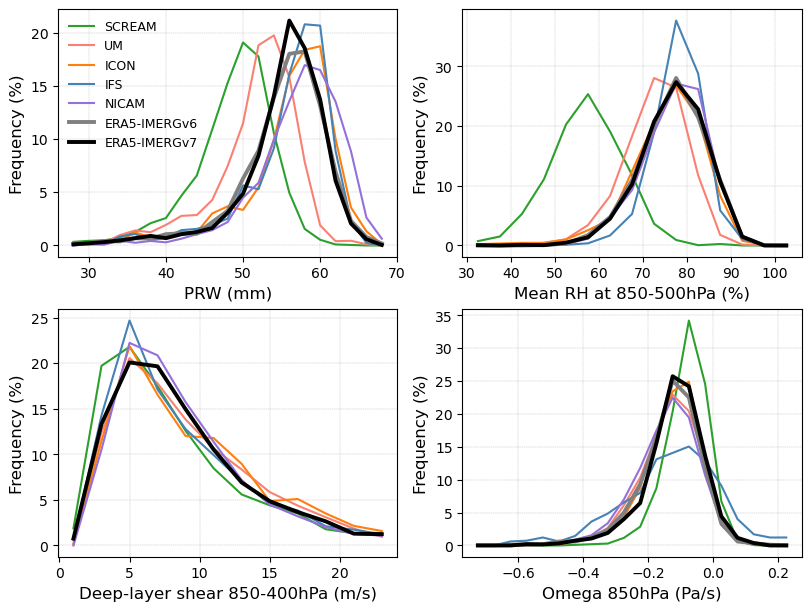

In [18]:
# Analysis parameters
RR = 2  # Radius (degrees)
TT = 0  # Time offset (0 = initiation)
CRIT = 'min2_longremoved'  # Which dataset to use

# Select variables to plot
vars_to_plot = ['prw', 'free_rh', 'dShear', 'omega850']

# Create subplots (2x2 grid)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), constrained_layout=True)
axes = axes.flatten()

# Loop through variables (subplots)
for ax, var in zip(axes, vars_to_plot):
    
    # Get settings for this variable
    if var not in VAR_SETTINGS:
        print(f"Skipping {var}: No bin settings defined.")
        continue
    
    bins = VAR_SETTINGS[var]['bins']
    mid_bins = 0.5 * (bins[1:] + bins[:-1])  # Calculate x-axis midpoints
    
    # Loop through models (lines)
    for model in MODEL_STYLES.keys():
        
        # 1. Retrieve Data
        try:
            df = processed_data[model][CRIT][var]
        except KeyError:
            continue  # Skip if data doesn't exist
        
        if df is None: 
            continue
        
        # 2. Filter Data (Radius & Time)
        subset = df[(df.radius == RR) & (df.time_offset_hours == TT)]
        
        if subset.empty:
            continue
        
        # 3. Calculate Histogram
        counts, _ = np.histogram(subset['mean'].values, bins=bins, density=False)
        
        # Avoid division by zero
        total_counts = counts.sum()
        if total_counts > 0:
            percentages = (counts / total_counts) * 100
        else:
            percentages = np.zeros_like(counts)
        
        # 4. Plot
        style = MODEL_STYLES[model]
        ax.plot(mid_bins, percentages, 
                color=style['color'], 
                label=style['label'], 
                linewidth=style['lw'],
                linestyle=style.get('ls', '-'))
    
    # Subplot Formatting
    ax.set_xlabel(VAR_SETTINGS[var]['xlabel'], fontsize=12)
    ax.set_ylabel('Frequency (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('white')
    ax.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.spines['left'].set_color('k')
    ax.spines['bottom'].set_color('k')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    # Add legend to first plot
    if var == vars_to_plot[0]:
        ax.legend(fontsize=9, loc='upper left', frameon=False)

plt.savefig('plots/distribution_4var_init.png', dpi=300, bbox_inches='tight')
plt.show()

## Appendix A: Understanding the MCS Filtering Workflow

The MCS filtering is performed in multiple stages, with outputs saved at each step:

### Stage 1: Initial MCS Track Filtering (`MCS_filter` function)

This applies the base filtering criteria to raw MCS track files (the `mcs_tracks_final_*.nc` files):

- **Spatial**: Tropical region (-30°S to 30°N)
- **Land fraction**: <10% over entire track lifetime (from MCS track file's `pf_landfrac`)
- **Track quality**: No splits at initiation, no merging
- **MCS definition**: Initial timesteps are non-MCS status, stable MCS status, peak rain during MCS status

**Input**: Raw MCS track files (`mcs_tracks_final_*.nc`)  
**Output**: `df_trop_<model>_min2.pkl` files

### Stage 2: Circular Land Fraction Filtering

Additional filtering based on **circular land fraction** computed around track centroids.

**Key difference from Stage 1**: 
- Stage 1 uses `pf_landfrac` from the MCS track file (land fraction within the precipitation feature)
- Stage 2 uses separately computed land fractions within **circular areas** at multiple radii (2°, 3.5°, 5°)

This ensures MCS tracks are in predominantly oceanic environments at the analysis scale.

**Workflow**:
1. Load circular land fraction parquet files (from `get_land_fractions.py` script)
2. Merge with Stage 1 filtered tracks
3. Filter tracks where `total_land_fraction_track <= 0.1` at radius=2°

**Input**: `df_trop_<model>_min2.pkl` + circular land fraction parquet files  
**Output**: `with_circular_lffiltered_<model>_min2_r2.pkl` files ← **These are what we load in this notebook**

### Stage 3: Duration Filtering (optional, done in analysis)

Remove long-duration outliers (>90th percentile) to focus on typical MCS events.

**Applied**: In the `process_all_data()` function, creating `'<crit>_longremoved'` datasets

### Summary of Filter Sequence

```
Raw MCS tracks (mcs_tracks_final_*.nc)
    ↓ [MCS_filter: tropical, oceanic, quality checks]
df_trop_<model>_min2.pkl
    ↓ [Circular land fraction filter at r=2°]
with_circular_lffiltered_<model>_min2_r2.pkl  ← We start here
    ↓ [Optional: remove long durations]
Final analysis dataset
```

## Appendix B: Environmental Data Structure

The environmental variable parquet files contain the following key columns:

- **track_id**: Unique identifier for each MCS track
- **time_idx**: Time step index within the track
- **time_offset_hours**: Hours relative to MCS initiation (negative = pre-convective period, 0 = initiation, positive = during track)
- **radius**: Radius of circular area (degrees) around MCS centroid
- **data_time**: Actual timestamp of the environmental data
- **mean, median, min, max, std**: Statistics of the variable within the circular area
- **count, num_valid**: Number of grid points used in calculation

### Time Coverage

- **Pre-convective period**: -24 to -3 hours before initiation. Some models (ICON, NICAM) only have 6h output for 3D variables.
- **Track lifetime**: 0 hours (initiation) through end of track

### Spatial Coverage

Multiple radii are used to capture different scales (2, 3.5, 5 degrees). We chose 2 degree for the analysis

## Summary

This notebook demonstrates the complete MCS environmental analysis workflow:

1. ✅ Load pre-extracted environmental variables and filtered MCS tracks
2. ✅ Process data using dictionary-based approach for efficient multi-model handling
3. ✅ Apply unit conversions and model-specific transformations
4. ✅ Filter data by land fraction and duration criteria
5. ✅ Visualize environmental conditions at MCS initiation

All heavy computation (filtering, extraction) is done via utility functions in `mcs_analysis_utils.py`, keeping the notebook clean and readable.

### Next Steps

- Modify `VAR_SETTINGS` to analyze additional variables
- Change `RR` and `TT` to examine different radii and time offsets
- Use `CRIT = 'min2_longremoved'` to analyze data with long durations removed